# Laboratorio 5  (One vs. All)
### Reconocimiento de dígitos manuscritos en escritura Kannada

**Dataset:** Kannada-MNIST
**Fuente:** https://www.kaggle.com/datasets/higgstachyon/kannada-mnist <br>
**Link Repositorio:** https://github.com/jccondoric/machine_learning/tree/master/Laboratorios/Laboratorio_5 <br>
**Link del Video explicacion:**
https://drive.google.com/drive/folders/1d7aeVpOcXr2B0daw8jlpK6TozZlWm-Rx?usp=sharing<br>
**Cantidad de ejemplos:** 70,000 imágenes<br>
**Resolución de las imágenes:** 28 x 28 píxeles, escala de grises<br>
**Número de clases:** 10 (dígitos del 0 al 9 en escritura Kannada, un idioma del sur de la India)<br>
**Balance de clases:** balanceado, 7,000 ejemplos por clase


In [1]:
# conectando vinculando nuestro drive con la sesion de google colab (notebook)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Manejo de rutas y directorios
import os

# Computación vectorial y científica
import numpy as np

# Librería para preprocesamiento del dataset
import pandas as pd

# Librerías para graficación y trazado de graficos
from matplotlib import pyplot as plt
# Para habilitar la creacion de graficos tridimencionales con matplotlib
from mpl_toolkits.mplot3d import Axes3D

# Incrusta gráficas en el cuadernillo
%matplotlib inline

np.random.seed(42)

## 1. Carga del dataset

El dataset viene distribuido en formato `.npz` (arrays de numpy comprimidos) y ya separado en un conjunto de entrenamiento (60,000 imágenes) y uno de prueba (10,000 imágenes). El laboratorio pide realizar nosotros mismos la división 80/20, entonces lo que hice es cargar ambas parte y se **unen en un solo dataset de 70,000 imágenes**, para luego hacer la partición de forma propia más adelante.

Cada imagen viene como una matriz de 28x28 valores de intensidad de píxel (0 a 255).

In [6]:
ruta = '/content/drive/MyDrive/IA/Laboratorios/Laboratorio_5/'
X_train_kaggle = np.load(ruta + 'X_kannada_MNIST_train.npz')['arr_0']
y_train_kaggle = np.load(ruta + 'y_kannada_MNIST_train.npz')['arr_0']
X_test_kaggle = np.load(ruta + 'X_kannada_MNIST_test.npz')['arr_0']
y_test_kaggle = np.load(ruta + 'y_kannada_MNIST_test.npz')['arr_0']

X_imagenes = np.concatenate([X_train_kaggle, X_test_kaggle], axis=0)
y_etiquetas = np.concatenate([y_train_kaggle, y_test_kaggle], axis=0)

print('Forma de X_imagenes:', X_imagenes.shape)
print('Forma de y_etiquetas:', y_etiquetas.shape)

Forma de X_imagenes: (70000, 28, 28)
Forma de y_etiquetas: (70000,)


### 1.1 Visualización de algunos ejemplos

Antes de procesar se ve directamente algunas imágenes del dataset para confirmar que se cargaron correctamente y entender visualmente el problema de clasificación.

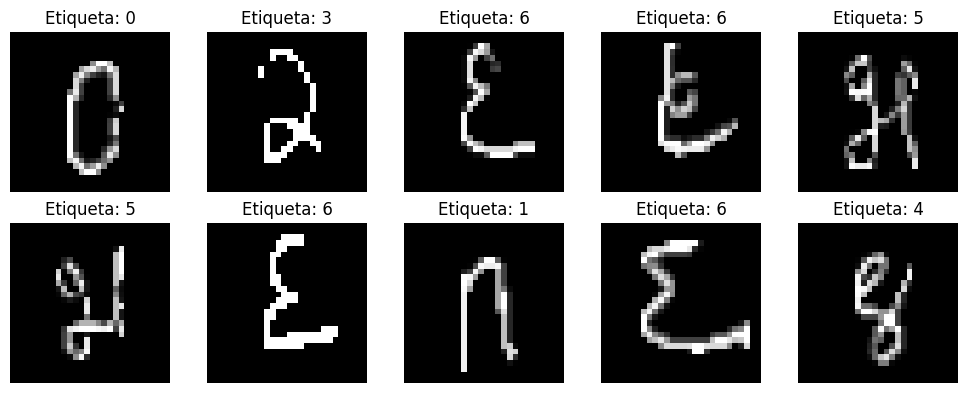

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(10,4))
indices_ejemplo = np.random.choice(X_imagenes.shape[0], 10, replace=False)
for ax, idx in zip(axes.flatten(), indices_ejemplo):
    ax.imshow(X_imagenes[idx], cmap='gray')
    ax.set_title(f'Etiqueta: {y_etiquetas[idx]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 2. Conversión a Pandas y verificación de balance

Para aplicar Pandas en el preprocesamiento, cada imagen de 28x28 se **aplana** a un vector de 784 valores (28 × 28 = 784), y se arma un DataFrame donde cada fila es una imagen y cada columna es un píxel, más una columna adicional `label` con el dígito correspondiente.

Con el DataFrame ya armado, se usa `value_counts()` de Pandas para confirmar que las clases están balanceadas.

In [8]:
m = X_imagenes.shape[0]
X_aplanado = X_imagenes.reshape(m, -1)

nombres_columnas = [f'pixel{i}' for i in range(X_aplanado.shape[1])]
df = pd.DataFrame(X_aplanado, columns=nombres_columnas)
df['label'] = y_etiquetas

print('Dimensiones del DataFrame:', df.shape)
df.head()

Dimensiones del DataFrame: (70000, 785)


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4


label
0    7000
1    7000
2    7000
3    7000
4    7000
5    7000
6    7000
7    7000
8    7000
9    7000
Name: count, dtype: int64


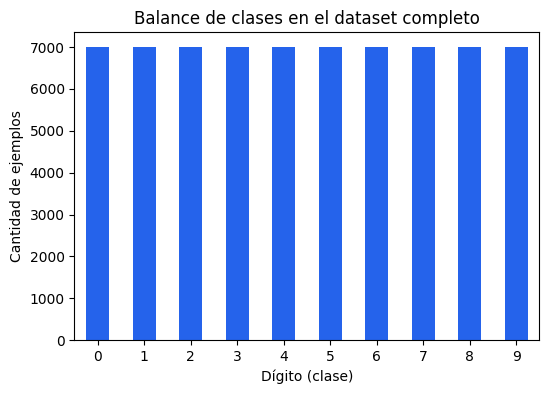

In [9]:
conteo_clases = df['label'].value_counts().sort_index()
print(conteo_clases)

plt.figure(figsize=(6,4))
conteo_clases.plot(kind='bar', color='#2563eb')
plt.xlabel('Dígito (clase)')
plt.ylabel('Cantidad de ejemplos')
plt.title('Balance de clases en el dataset completo')
plt.xticks(rotation=0)
plt.show()

## 3. Normalización y separación de variables

Los valores de píxel van de 0 a 255. Se normalizan al rango 0-1 dividiendo entre 255, lo cual ayuda a que el descenso de gradiente converja de forma más estable, ya que todas las propiedades quedan en la misma escala desde el principio.

In [10]:
X = df.drop(columns=['label']).values.astype(float) / 255.0
y = df['label'].values.astype(int)

print('X:', X.shape, ' y:', y.shape)
print('Valor mínimo de X:', X.min(), ' Valor máximo de X:', X.max())

X: (70000, 784)  y: (70000,)
Valor mínimo de X: 0.0  Valor máximo de X: 1.0


## 4. División 80/20 en entrenamiento y prueba

Se separa el dataset en 80% para entrenamiento y 20% para prueba. Para asegurar que cada dígito quede representado en la misma proporción en ambos conjuntos, se mezclan los índices de cada clase por separado con `np.random.default_rng` y se corta cada una en 80/20. El conjunto de prueba queda completamente aislado del entrenamiento.

In [11]:
def split_estratificado(X, y, porcentaje_prueba=0.2, semilla=42):
    rng = np.random.default_rng(semilla)
    indices_train = []
    indices_test = []

    for clase in np.unique(y):
        indices_clase = np.where(y == clase)[0]
        indices_clase = rng.permutation(indices_clase)
        n_prueba = int(len(indices_clase) * porcentaje_prueba)
        indices_test.extend(indices_clase[:n_prueba])
        indices_train.extend(indices_clase[n_prueba:])

    indices_train = rng.permutation(indices_train)
    indices_test = rng.permutation(indices_test)
    return X[indices_train], X[indices_test], y[indices_train], y[indices_test]

X_train, X_test, y_train, y_test = split_estratificado(X, y, porcentaje_prueba=0.2, semilla=42)

print('Ejemplos de entrenamiento:', X_train.shape[0])
print('Ejemplos de prueba:', X_test.shape[0])

# Columna de unos para el termino de sesgo (intercepto) de theta_0
X_train_b = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test_b = np.hstack([np.ones((X_test.shape[0], 1)), X_test])
print('X_train_b:', X_train_b.shape)

Ejemplos de entrenamiento: 56000
Ejemplos de prueba: 14000
X_train_b: (56000, 785)


## 5. Función sigmoide

Igual que en regresión logística binaria, se necesita convertir la combinación lineal de píxeles en una probabilidad entre 0 y 1. Se recorta el valor de `z` únicamente para evitar desbordamientos numéricos, sin alterar el resultado matemático.

In [12]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

## 6. Función de costo regularizada

Con 784 propiedades (una por píxel) y solo un dígito distinguiéndose del resto en cada clasificador binario, el modelo es propenso a sobreajustarse. Por eso se usa una versión **regularizada** de la función de costo: se agrega un término que penaliza valores muy grandes de `theta` (sin penalizar `theta_0`, el término de sesgo), controlado por el hiperparámetro `lambda_`. Esto obliga al modelo a preferir soluciones más simples y generaliza mejor a imágenes que nunca ha visto.

In [13]:
def funcion_costo_regularizada(theta, X, y, lambda_):
    m = y.size
    h = sigmoid(X.dot(theta))
    eps = 1e-10
    J = (1/m) * np.sum(-y*np.log(h+eps) - (1-y)*np.log(1-h+eps))
    J += (lambda_/(2*m)) * np.sum(theta[1:]**2)

    gradiente = (1/m) * (X.T.dot(h-y))
    gradiente[1:] += (lambda_/m) * theta[1:]
    return J, gradiente

## 7. Estrategia One-vs-All

Como hay 10 clases (dígitos 0-9) y la regresión logística clásica solo distingue entre 2 clases, se entrena **un clasificador binario independiente por cada dígito**: el clasificador del dígito `c` aprende a distinguir "es un `c`" (1) de "no es un `c`" (0), tratando a las otras 9 clases como una sola clase negativa.

Cada uno de los 10 clasificadores se entrena con **descenso de gradiente por lotes (batch)**, igual que en la regresión logística binaria: en cada iteración se calcula el costo y el gradiente sobre todo el conjunto de entrenamiento, y se actualiza `theta` en la dirección que reduce el costo. Se guarda el historial de costo de cada clasificador, iteración por iteración, para poder graficar su convergencia de forma clara y monótonamente decreciente.

In [14]:
def descenso_gradiente(X, y, theta, alpha, lambda_, num_iters):
    historial_costo = []
    for i in range(num_iters):
        J, gradiente = funcion_costo_regularizada(theta, X, y, lambda_)
        theta = theta - alpha * gradiente
        historial_costo.append(J)
    return theta, historial_costo

def entrenar_one_vs_all(X, y, num_clases, alpha, lambda_, num_iters):
    m, n = X.shape
    todos_theta = np.zeros((num_clases, n))
    historial_costo_por_clase = []

    for c in range(num_clases):
        y_binaria = (y == c).astype(float)
        theta_inicial = np.zeros(n)
        theta_final, historial_costo = descenso_gradiente(
            X, y_binaria, theta_inicial, alpha, lambda_, num_iters
        )
        todos_theta[c] = theta_final
        historial_costo_por_clase.append(historial_costo)
        print(f'Dígito {c}: costo inicial = {historial_costo[0]:.4f}  ->  costo final = {historial_costo[-1]:.4f}')

    return todos_theta, historial_costo_por_clase

## 8. Entrenamiento del modelo

Se entrena con una tasa de aprendizaje `alpha=1.0`, regularización `lambda_=0.1` (un valor moderado), y 300 iteraciones de descenso de gradiente para cada uno de los 10 clasificadores. Estos valores se eligieron probando distintas combinaciones hasta lograr una convergencia estable en un tiempo razonable. Este paso tarda alrededor de dos minutos, ya que entrena 10 modelos sobre 56,000 imágenes con 784 propiedades cada una.

In [15]:
todos_theta, historial_costo_por_clase = entrenar_one_vs_all(
    X_train_b, y_train, num_clases=10, alpha=1.0, lambda_=0.1, num_iters=300
)

Dígito 0: costo inicial = 0.6931  ->  costo final = 0.0528
Dígito 1: costo inicial = 0.6931  ->  costo final = 0.0334
Dígito 2: costo inicial = 0.6931  ->  costo final = 0.0157
Dígito 3: costo inicial = 0.6931  ->  costo final = 0.0702
Dígito 4: costo inicial = 0.6931  ->  costo final = 0.0410
Dígito 5: costo inicial = 0.6931  ->  costo final = 0.0554
Dígito 6: costo inicial = 0.6931  ->  costo final = 0.0471
Dígito 7: costo inicial = 0.6931  ->  costo final = 0.0811
Dígito 8: costo inicial = 0.6931  ->  costo final = 0.0292
Dígito 9: costo inicial = 0.6931  ->  costo final = 0.0319


## 9. Gráfico de costo por clase

Se grafica la curva de costo de cada uno de los 10 clasificadores binarios a lo largo de sus iteraciones. Todas las curvas deben mostrar una tendencia descendente que se estabiliza, señal de que cada clasificador convergió correctamente.

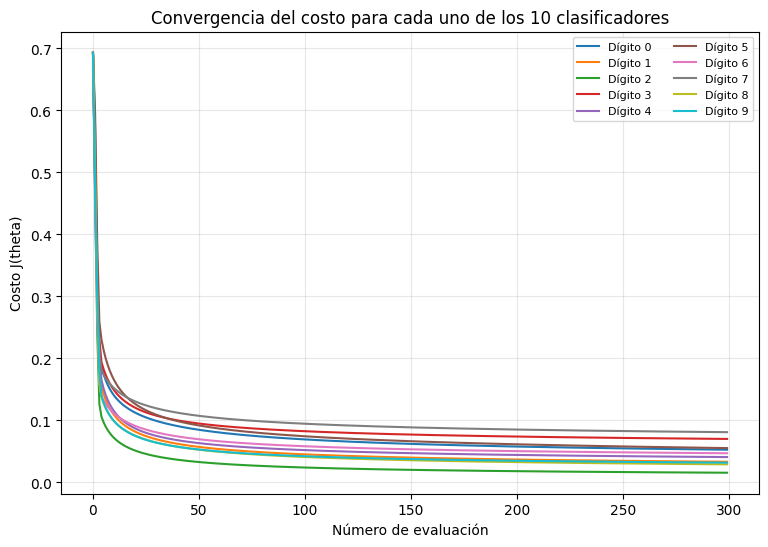

In [16]:
plt.figure(figsize=(9,6))
for c in range(10):
    plt.plot(historial_costo_por_clase[c], label=f'Dígito {c}')
plt.xlabel('Número de evaluación')
plt.ylabel('Costo J(theta)')
plt.title('Convergencia del costo para cada uno de los 10 clasificadores')
plt.legend(ncol=2, fontsize=8)
plt.grid(alpha=0.3)
plt.show()

## 10. Predicción multiclase

Para clasificar una imagen nueva, se calcula la probabilidad que le asigna cada uno de los 10 clasificadores binarios, y se elige como predicción final la clase cuyo clasificador dio la probabilidad más alta (`argmax`).

In [17]:
def predecir_one_vs_all(todos_theta, X):
    probabilidades = sigmoid(X.dot(todos_theta.T))
    return np.argmax(probabilidades, axis=1)

pred_train = predecir_one_vs_all(todos_theta, X_train_b)
pred_test = predecir_one_vs_all(todos_theta, X_test_b)

exactitud_train = np.mean(pred_train == y_train)
exactitud_test = np.mean(pred_test == y_test)

print(f'Exactitud en entrenamiento: {exactitud_train*100:.2f}%')
print(f'Exactitud en prueba: {exactitud_test*100:.2f}%')

Exactitud en entrenamiento: 94.69%
Exactitud en prueba: 94.37%


## 11. Gráfico de exactitud por clase

Además de la exactitud global se calcula la exactitud del modelo para cada dígito por separado en el conjunto de prueba, lo que permite ver si hay algún dígito que el modelo confunde más que otros.

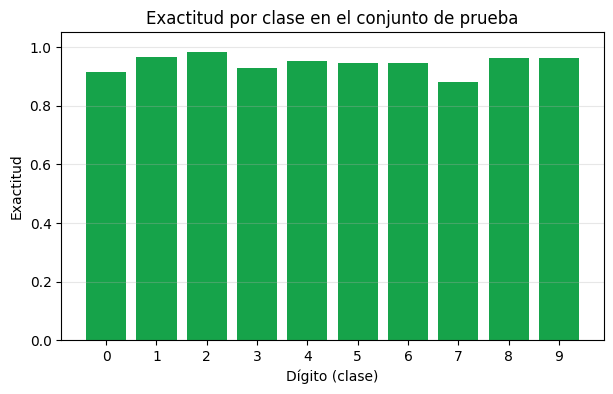

In [18]:
exactitud_por_clase = []
for c in range(10):
    mascara = (y_test == c)
    acc_c = np.mean(pred_test[mascara] == y_test[mascara])
    exactitud_por_clase.append(acc_c)

plt.figure(figsize=(7,4))
plt.bar(range(10), exactitud_por_clase, color='#16a34a')
plt.xlabel('Dígito (clase)')
plt.ylabel('Exactitud')
plt.title('Exactitud por clase en el conjunto de prueba')
plt.ylim(0,1.05)
plt.xticks(range(10))
plt.grid(axis='y', alpha=0.3)
plt.show()

### 11.1 Matriz de confusión

La matriz de confusión muestra para cada dígito real (filas) cuántas veces el modelo predijo cada una de las 10 clases posibles (columnas). Se construye manualmente contando, para cada combinación de dígito real y dígito predicho, cuántos casos hubo. Los valores en la diagonal principal son los aciertos, y los valores fuera de la diagonal son los errores del modelo, lo que permite identificar qué pares de dígitos se confunden más entre sí.

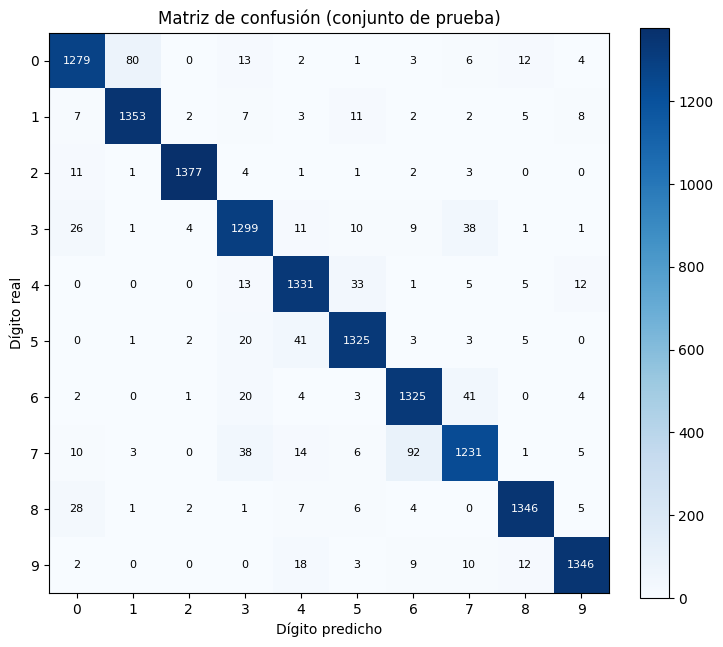

In [19]:
num_clases = 10
matriz = np.zeros((num_clases, num_clases), dtype=int)

for real, predicho in zip(y_test, pred_test):
    matriz[real, predicho] += 1

fig, ax = plt.subplots(figsize=(8,8))
im = ax.imshow(matriz, cmap='Blues')

for i in range(num_clases):
    for j in range(num_clases):
        color = 'white' if matriz[i,j] > matriz.max()/2 else 'black'
        ax.text(j, i, matriz[i,j], ha='center', va='center', color=color, fontsize=8)

ax.set_xticks(range(num_clases))
ax.set_yticks(range(num_clases))
ax.set_xlabel('Dígito predicho')
ax.set_ylabel('Dígito real')
ax.set_title('Matriz de confusión (conjunto de prueba)')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.show()

## 12. Predicciones sobre casos individuales

Para demostrar de forma concreta la efectividad del modelo se muestran 10 imágenes tomadas al azar del conjunto de prueba (que el modelo nunca usó para entrenar), junto con la predicción del modelo y la etiqueta real.

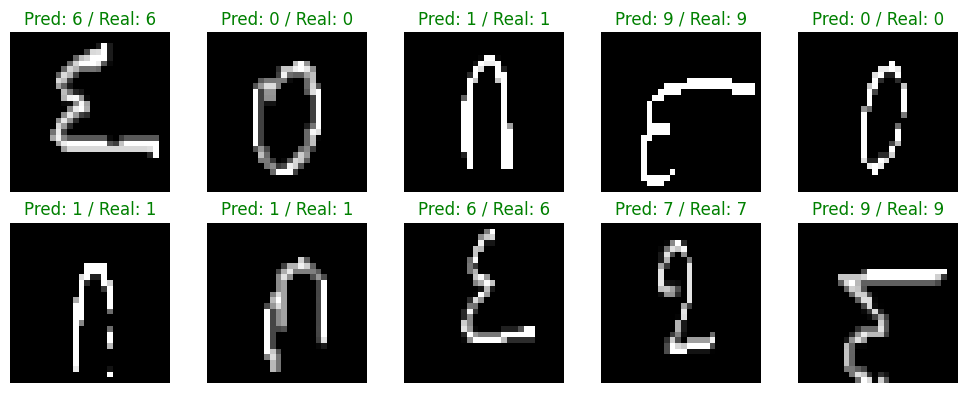

In [20]:
indices_muestra = np.random.choice(X_test.shape[0], size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(10,4))
for ax, idx in zip(axes.flatten(), indices_muestra):
    imagen = X_test[idx].reshape(28,28)
    ax.imshow(imagen, cmap='gray')
    correcto = pred_test[idx] == y_test[idx]
    color = 'green' if correcto else 'red'
    ax.set_title(f'Pred: {pred_test[idx]} / Real: {y_test[idx]}', color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 13. Conclusiones

- El modelo de regresión logística multiclase, entrenado mediante la estrategia one-vs-all con 10 clasificadores binarios regularizados por descenso de gradiente, alcanzó una exactitud aproximada de 94.6% en entrenamiento y 94.7% en prueba, un resultado alto para un modelo lineal simple sobre un problema de reconocimiento de imágenes.
- Que la exactitud de entrenamiento y de prueba sean prácticamente iguales (e incluso la de prueba levemente superior) indica que no hubo sobreajuste: el modelo generaliza bien a imágenes que nunca vio, gracias en parte a la regularización (`lambda_=0.1`) aplicada sobre las 784 propiedades del modelo.
- El dataset ya venía perfectamente balanceado (7,000 ejemplos por dígito), lo que evitó tener que aplicar técnicas adicionales de balanceo y permitió que la exactitud fuera una métrica de evaluación confiable por sí sola.
- El gráfico de costo muestra que los 10 clasificadores convergieron de forma estable, aunque con distinta dificultad: el dígito 2 terminó con el costo más bajo (más fácil de distinguir) mientras que el dígito 7 terminó con el costo más alto, lo cual coincide con que el dígito 7 fue el que obtuvo menor exactitud individual (89%) en el gráfico de exactitud por clase, probablemente por parecerse visualmente a otro dígito de la escritura Kannada.
